# ESG Risk Analysis of S&P 500 Companies

This notebook presents the analytical workflow behind an interactive ESG Risk Analysis Dashboard developed with Python and Streamlit. The project focuses on exploring ESG risk patterns across S&P 500 companies through descriptive analysis, visualisation, and dashboard design.

## 1. Analytical Problem and Target User

The aim of this project is to analyse ESG risk scores of S&P 500 companies and turn the analysis into an interactive tool for users. The project investigates company-level ESG profiles, sector-level differences, ESG component patterns, and ranking results.

The intended users are business students, investors, and general users who want to explore ESG-related corporate risk in a more interactive and accessible way.

## 2. Data Source

The dataset used in this project is the **S&P 500 ESG Risk Ratings** dataset. It includes company information and ESG-related indicators such as total ESG risk score, environmental risk score, social risk score, governance risk score, sector, industry, and employee size.

This dataset was selected because it is directly relevant to business analysis and provides multiple dimensions that can support filtering, comparison, and visualisation.

Source: Kaggle, "S&P 500 ESG Risk Ratings" dataset  
URL: https://www.kaggle.com/datasets/pritish509/s-and-p-500-esg-risk-ratings  
Access date: 14 April 2026

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 3. Load Data

The first step is to load the dataset and inspect its structure.

In [3]:
df = pd.read_csv("SP 500 ESG Risk Ratings.csv")
df.head()

,Symbol,Name,Address,Sector,Industry,Full Time Employees,Description,Total ESG Risk score,Environment Risk Score,Governance Risk Score,Social Risk Score,Controversy Level,Controversy Score,ESG Risk Percentile,ESG Risk Level
0,ENPH,"Enphase Energy, Inc.","47281 Bayside Parkway\nFremont, CA 94538\nUnit...",Technology,Solar,"3,157","Enphase Energy, Inc., together with its subsid...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EMN,Eastman Chemical Company,"200 South Wilcox Drive\nKingsport, TN 37662\nU...",Basic Materials,Specialty Chemicals,"14,000",Eastman Chemical Company operates as a special...,25.3,12.8,6.6,5.8,Moderate Controversy Level,2.0,50th percentile,Medium
2,DPZ,Domino's Pizza Inc.,"30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...",Consumer Cyclical,Restaurants,"6,500","Domino's Pizza, Inc., through its subsidiaries...",29.2,10.6,6.3,12.2,Moderate Controversy Level,2.0,66th percentile,Medium
3,DAY,"Dayforce, Inc.","3311 East Old Shakopee Road\nMinneapolis, MN 5...",Technology,Software - Application,"9,084","Dayforce Inc., together with its subsidiaries,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DVA,Davita Inc.,"2000 16th Street\nDenver, CO 80202\nUnited States",Healthcare,Medical Care Facilities,"70,000",DaVita Inc. provides kidney dialysis services ...,22.6,0.1,8.4,14.1,Moderate Controversy Level,2.0,38th percentile,Medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Symbol                  503 non-null    object 
 1   Name                    503 non-null    object 
 2   Address                 502 non-null    object 
 3   Sector                  502 non-null    object 
 4   Industry                502 non-null    object 
 5   Full Time Employees     498 non-null    object 
 6   Description             502 non-null    object 
 7   Total ESG Risk score    430 non-null    float64
 8   Environment Risk Score  430 non-null    float64
 9   Governance Risk Score   430 non-null    float64
 10  Social Risk Score       430 non-null    float64
 11  Controversy Level       430 non-null    object 
 12  Controversy Score       403 non-null    float64
 13  ESG Risk Percentile     430 non-null    object 
 14  ESG Risk Level          430 non-null    ob

In [5]:
df.isna().sum()

Symbol                      0
Name                        0
Address                     1
Sector                      1
Industry                    1
Full Time Employees         5
Description                 1
Total ESG Risk score       73
Environment Risk Score     73
Governance Risk Score      73
Social Risk Score          73
Controversy Level          73
Controversy Score         100
ESG Risk Percentile        73
ESG Risk Level             73
dtype: int64

## 4. Data Cleaning and Preparation

To prepare the dataset for analysis, key score-related columns are converted into numeric format. Invalid values are coerced into missing values. Rows with missing company names, sectors, or total ESG risk scores are removed, and duplicate company records are also dropped.

In [7]:
numeric_cols = [
    "Total ESG Risk score",
    "Environment Risk Score",
    "Social Risk Score",
    "Governance Risk Score",
    "Full Time Employees"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
df = df.dropna(subset=["Total ESG Risk score", "Sector", "Name"])
df = df.drop_duplicates(subset=["Name"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 430 entries, 1 to 502
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Symbol                  430 non-null    object 
 1   Name                    430 non-null    object 
 2   Address                 430 non-null    object 
 3   Sector                  430 non-null    object 
 4   Industry                430 non-null    object 
 5   Full Time Employees     12 non-null     float64
 6   Description             430 non-null    object 
 7   Total ESG Risk score    430 non-null    float64
 8   Environment Risk Score  430 non-null    float64
 9   Governance Risk Score   430 non-null    float64
 10  Social Risk Score       430 non-null    float64
 11  Controversy Level       430 non-null    object 
 12  Controversy Score       403 non-null    float64
 13  ESG Risk Percentile     430 non-null    object 
 14  ESG Risk Level          430 non-null    object 

## 5. Feature Engineering

To improve readability, I created a categorical variable called **ESG Risk Category** based on the total ESG risk score. This makes it easier to classify firms into broad risk groups.

In [10]:
def classify_esg(score):
    if score < 10:
        return "Negligible"
    elif score < 20:
        return "Low"
    elif score < 30:
        return "Medium"
    elif score < 40:
        return "High"
    else:
        return "Severe"

df["ESG Risk Category"] = df["Total ESG Risk score"].apply(classify_esg)

In [11]:
df[["Name", "Total ESG Risk score", "ESG Risk Category"]].head()

,Name,Total ESG Risk score,ESG Risk Category
1,Eastman Chemical Company,25.3,Medium
2,Domino's Pizza Inc.,29.2,Medium
4,Davita Inc.,22.6,Medium
5,"Darden Restaurants, Inc.",27.5,Medium
6,Zoetis Inc.,18.8,Low


In [12]:
df["ESG Risk Category"].value_counts()

ESG Risk Category
Medium        185
Low           185
High           51
Negligible      6
Severe          3
Name: count, dtype: int64

## 6. Descriptive Overview

This section provides a basic statistical overview of the ESG risk scores in the dataset.

In [13]:
df["Total ESG Risk score"].describe()

count    430.000000
mean      21.533721
std        6.889176
min        7.100000
25%       16.400000
50%       21.050000
75%       26.000000
max       41.700000
Name: Total ESG Risk score, dtype: float64

In [14]:
print("Number of companies:", len(df))
print("Average ESG risk:", round(df["Total ESG Risk score"].mean(), 2))
print("Lowest ESG risk:", round(df["Total ESG Risk score"].min(), 2))
print("Highest ESG risk:", round(df["Total ESG Risk score"].max(), 2))

Number of companies: 430
Average ESG risk: 21.53
Lowest ESG risk: 7.1
Highest ESG risk: 41.7


## 7. Distribution of ESG Risk Scores

A histogram is used to show how total ESG risk scores are distributed across companies.

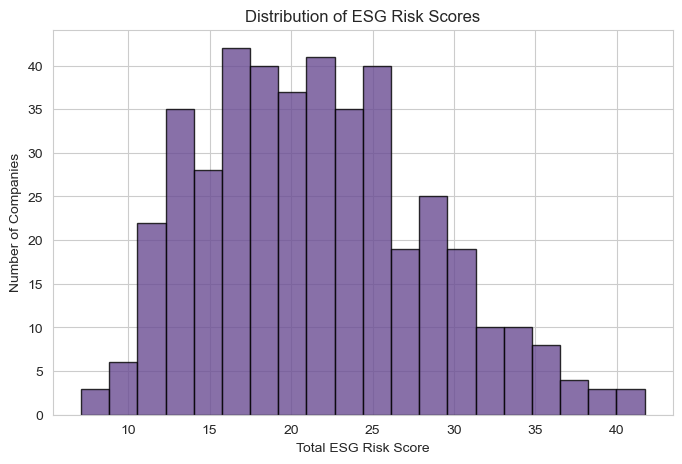

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df["Total ESG Risk score"], bins=20, color="#6a4c93", edgecolor="black", alpha=0.8)
plt.xlabel("Total ESG Risk Score")
plt.ylabel("Number of Companies")
plt.title("Distribution of ESG Risk Scores")
plt.show()

The distribution indicates that ESG risk varies considerably across firms rather than clustering around a single narrow range.

## 8. Sector Analysis

Sector analysis helps identify whether some industries tend to have systematically higher or lower ESG risk scores.

In [16]:
sector_avg = df.groupby("Sector")["Total ESG Risk score"].mean().sort_values()
sector_avg

Sector
Real Estate               13.085714
Technology                16.924590
Consumer Cyclical         19.227451
Communication Services    19.414286
Healthcare                20.577358
Financial Services        21.190476
Industrials               24.013333
Consumer Defensive        25.445455
Utilities                 26.710714
Basic Materials           26.715789
Energy                    32.335000
Name: Total ESG Risk score, dtype: float64

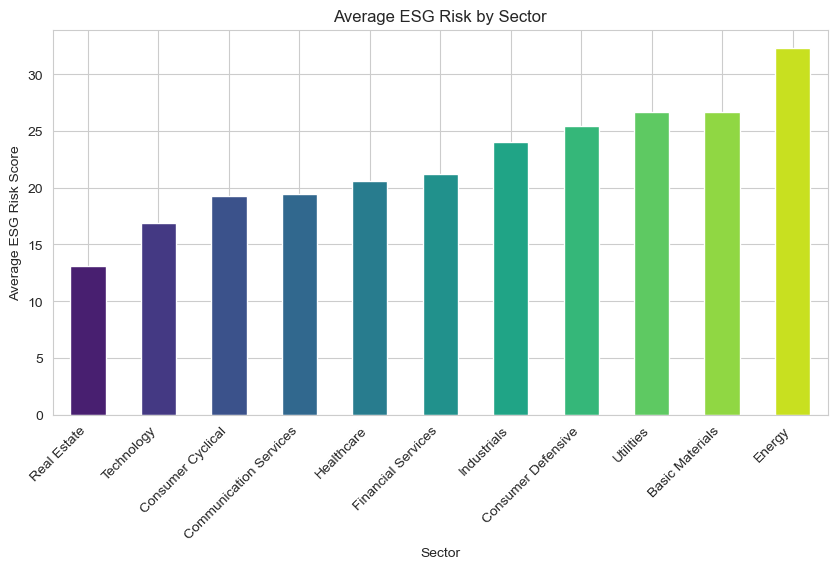

In [17]:
plt.figure(figsize=(10, 5))
sector_avg.plot(kind="bar", color=sns.color_palette("viridis", len(sector_avg)))
plt.ylabel("Average ESG Risk Score")
plt.title("Average ESG Risk by Sector")
plt.xticks(rotation=45, ha="right")
plt.show()

This chart shows sector-level differences in average ESG risk. Such variation may reflect different operational exposures, regulatory pressures, or sustainability challenges across industries.

## 9. Average ESG Component Scores

To understand the composition of ESG risk, I compare the average values of the environment, social, and governance risk scores.

In [18]:
component_means = df[
    ["Environment Risk Score", "Social Risk Score", "Governance Risk Score"]
].mean()

component_means

Environment Risk Score    5.739767
Social Risk Score         9.070465
Governance Risk Score     6.725116
dtype: float64

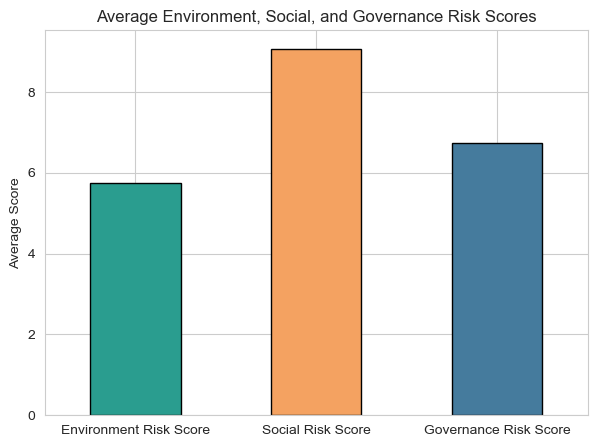

In [19]:
plt.figure(figsize=(7, 5))
component_means.plot(
    kind="bar",
    color=["#2a9d8f", "#f4a261", "#457b9d"],
    edgecolor="black"
)
plt.ylabel("Average Score")
plt.title("Average Environment, Social, and Governance Risk Scores")
plt.xticks(rotation=0)
plt.show()

Comparing these component averages helps show whether ESG risk is more strongly shaped by one dimension or is relatively balanced across all three.

## 10. Company Size and ESG Risk

The scatter plot below explores the relationship between company size, measured by full-time employees, and total ESG risk score.

In [20]:
scatter_data = df.dropna(subset=["Full Time Employees", "Total ESG Risk score"])
scatter_data.head()

,Symbol,Name,Address,Sector,Industry,Full Time Employees,Description,Total ESG Risk score,Environment Risk Score,Governance Risk Score,Social Risk Score,Controversy Level,Controversy Score,ESG Risk Percentile,ESG Risk Level,ESG Risk Category
19,WELL,Welltower Inc.,"4500 Dorr Street\nToledo, OH 43615-4040\nUnite...",Real Estate,REIT - Healthcare Facilities,533.0,"Welltower Inc. (NYSE:WELL), a REIT and S&P 500...",13.2,4.2,5.5,3.5,Low Controversy Level,1.0,7th percentile,Low,Low
38,VRSN,Verisign Inc,"12061 Bluemont Way\nReston, VA 20190\nUnited S...",Technology,Software - Infrastructure,907.0,"VeriSign, Inc., together with its subsidiaries...",21.3,4.7,5.8,10.8,Low Controversy Level,1.0,33rd percentile,Medium,Medium
40,VTR,"Ventas, Inc.","353 North Clark Street\nSuite 3300\nChicago, I...",Real Estate,REIT - Healthcare Facilities,486.0,Ventas Inc. (NYSE: VTR) is a leading S&P 500 r...,12.9,3.4,5.6,3.9,None Controversy Level,NaN,6th percentile,Low,Low
124,REG,Regency Centers Corporation,One Independent Drive\nSuite 114\nJacksonville...,Real Estate,REIT - Retail,492.0,Regency Centers is a preeminent national owner...,11.7,3.7,4.8,3.2,None Controversy Level,NaN,5th percentile,Low,Low
125,O,Realty Income Corporation,"11995 El Camino Real\nSan Diego, CA 92130\nUni...",Real Estate,REIT - Retail,418.0,"Realty Income, The Monthly Dividend Company, i...",15.5,4.4,5.7,5.3,Moderate Controversy Level,2.0,13th percentile,Low,Low


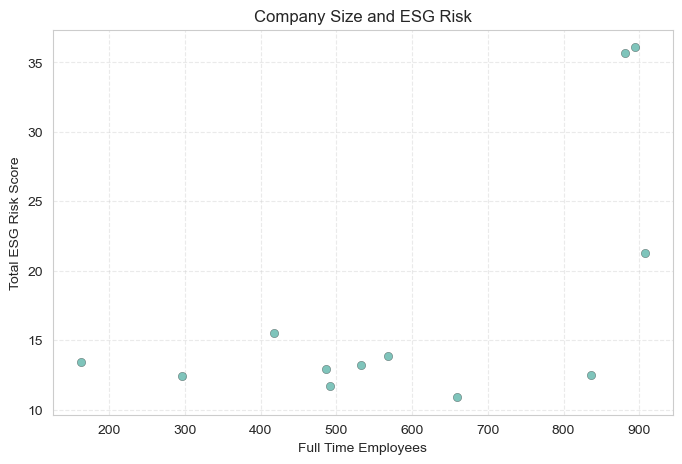

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_data["Full Time Employees"],
    scatter_data["Total ESG Risk score"],
    alpha=0.6,
    color="#2a9d8f",
    edgecolors="black",
    linewidths=0.3
)
plt.xlabel("Full Time Employees")
plt.ylabel("Total ESG Risk Score")
plt.title("Company Size and ESG Risk")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

This chart provides an intuitive way to inspect whether larger firms appear to face different ESG risk profiles from smaller firms. The relationship is visible, although it may not be strongly linear.

## 11. Correlation Matrix

A correlation matrix is used to examine the relationships among total ESG risk, ESG component scores, and company size.

In [22]:
corr_cols = [
    "Total ESG Risk score",
    "Environment Risk Score",
    "Social Risk Score",
    "Governance Risk Score",
    "Full Time Employees"
]

corr = df[corr_cols].corr()
corr

,Total ESG Risk score,Environment Risk Score,Social Risk Score,Governance Risk Score,Full Time Employees
Total ESG Risk score,1.000000,0.703659,0.694264,0.347539,0.633074
Environment Risk Score,0.703659,1.000000,0.066318,-0.220337,0.566287
Social Risk Score,0.694264,0.066318,1.000000,0.357514,0.635552
Governance Risk Score,0.347539,-0.220337,0.357514,1.000000,0.545996
Full Time Employees,0.633074,0.566287,0.635552,0.545996,1.000000


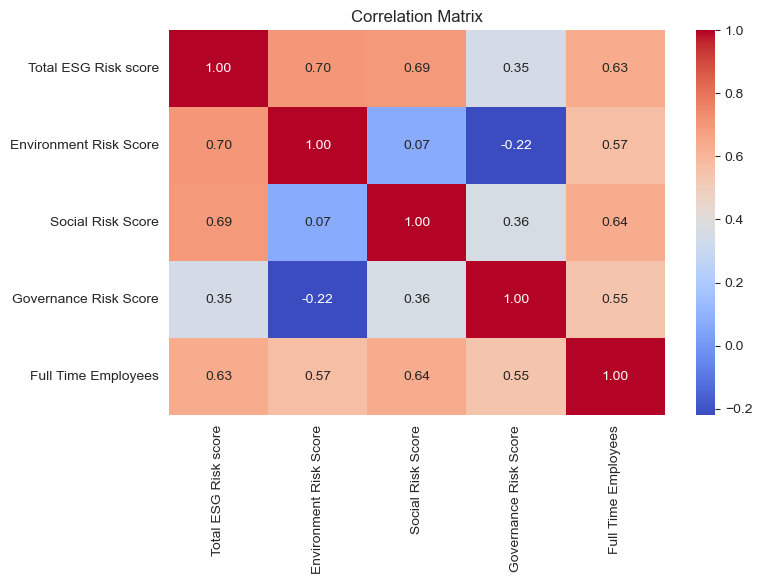

In [23]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix helps summarise how the main numeric variables move together. It is especially useful for understanding the association between total ESG risk and its component scores.

## 12. Example Company Comparison

A simple company comparison illustrates how two firms can differ across the total ESG score and the three ESG components.

In [24]:
company1 = df.iloc[0]["Name"]
company2 = df.iloc[1]["Name"]

d1 = df[df["Name"] == company1].iloc[0]
d2 = df[df["Name"] == company2].iloc[0]

compare = pd.DataFrame({
    "Total ESG": [d1["Total ESG Risk score"], d2["Total ESG Risk score"]],
    "Environment": [d1["Environment Risk Score"], d2["Environment Risk Score"]],
    "Social": [d1["Social Risk Score"], d2["Social Risk Score"]],
    "Governance": [d1["Governance Risk Score"], d2["Governance Risk Score"]],
}, index=[company1, company2])

compare

,Total ESG,Environment,Social,Governance
Eastman Chemical Company,25.3,12.8,5.8,6.6
Domino's Pizza Inc.,29.2,10.6,12.2,6.3


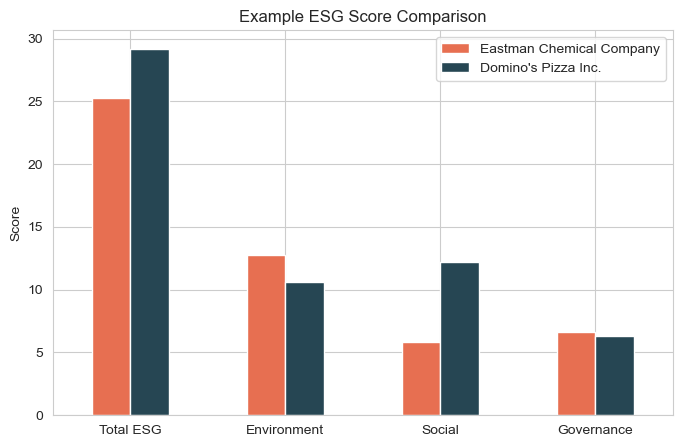

In [25]:
compare.T.plot(kind="bar", figsize=(8, 5), color=["#e76f51", "#264653"])
plt.ylabel("Score")
plt.title("Example ESG Score Comparison")
plt.xticks(rotation=0)
plt.show()

This comparison demonstrates the usefulness of company-level analysis, since firms can differ not only in total ESG risk but also in which ESG dimension contributes most to that risk.

## 13. Ranking Analysis

Ranking analysis highlights the best-performing and worst-performing firms in terms of ESG risk.

In [26]:
best = df.sort_values("Total ESG Risk score").head(10)
worst = df.sort_values("Total ESG Risk score", ascending=False).head(10)

best[["Name", "Sector", "Total ESG Risk score", "ESG Risk Category"]]

,Name,Sector,Total ESG Risk score,ESG Risk Category
288,"Hasbro, Inc.",Consumer Cyclical,7.1,Negligible
240,"Keysight Technologies, Inc.",Technology,7.6,Negligible
409,"Cbre Group, Inc.",Real Estate,8.0,Negligible
408,Cdw Corporation,Technology,9.2,Negligible
498,Accenture Plc,Technology,9.8,Negligible
451,"Avalonbay Communities, Inc.",Real Estate,9.8,Negligible
371,Crown Castle Inc.,Real Estate,10.1,Low
69,"The Interpublic Group of Companies, Inc.",Communication Services,10.3,Low
137,"Prologis, Inc.",Real Estate,10.3,Low
107,Seagate Technology Holdings Plcs,Technology,10.7,Low


In [27]:
worst[["Name", "Sector", "Total ESG Risk score", "ESG Risk Category"]]

,Name,Sector,Total ESG Risk score,ESG Risk Category
166,Occidental Petroleum Corporation,Energy,41.7,Severe
324,Exxon Mobil Corporation,Energy,41.6,Severe
297,General Electric Company,Industrials,40.5,Severe
434,Boeing Company,Industrials,39.6,High
465,Apa Corporation,Energy,38.8,High
56,Transdigm Group Incorporated,Industrials,38.7,High
219,Marathon Oil Corporation,Energy,37.7,High
502,3m Company,Industrials,37.3,High
129,"Quanta Services, Inc.",Industrials,36.9,High
400,Chevron Corporation,Energy,36.6,High


Rankings make it easier for users to quickly identify low-risk and high-risk companies without manually scanning the full dataset.

## 14. Key Insights

The analysis generated several important insights:

1. ESG risk scores vary substantially across sectors, suggesting that industry context matters.
2. The environment, social, and governance dimensions contribute differently to total ESG risk.
3. Company size and ESG risk can be explored visually, but the relationship is not necessarily strongly linear.
4. Total ESG risk is positively associated with component-level ESG scores.
5. Company comparison and ranking are useful for identifying relative ESG performance across firms.

## 15. Final Product

Based on the analytical workflow in this notebook, I developed an interactive Streamlit dashboard. The dashboard allows users to:
- filter firms by sector, risk score range, employee size, and ESG category;
- inspect single-company details;
- compare two companies;
- examine sector-level trends;
- explore ESG relationships;
- review top and bottom company rankings.

This transforms the Python analysis into a user-facing data product.

## 16. Limitations

This project has several limitations:

- The dataset is cross-sectional and does not show changes over time.
- Some variables contain missing values, especially company size data.
- The analysis is mainly descriptive and does not include predictive modelling.
- ESG scores depend on the methodology of the original data provider and may contain measurement limitations.

## 17. Conclusion

This notebook demonstrates a complete Python-based workflow from data loading and cleaning to analysis, visualisation, and interpretation. The final output is an interactive Streamlit dashboard designed to communicate ESG risk insights to users in a practical and accessible way.